In [1]:
import  tensorflow as tf
from  tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
housing=fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [3]:
X=housing.data
y=housing.target

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [5]:
print(len(X_train))
print(len(X_val))
print(len(X_test))

12384
3096
5160


In [6]:
print(X_train.dtype)

float64


In [7]:
df_X_train=pd.DataFrame(X_train,columns=housing.feature_names)
df_X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,10.2264,36.0,8.571429,1.142857,30.0,2.142857,38.63,-121.28
1,3.0912,40.0,4.396262,1.001869,1430.0,2.672897,36.84,-121.40
2,3.6087,10.0,6.317073,1.083624,827.0,2.881533,39.05,-121.07
3,2.4524,41.0,5.340116,1.188953,1430.0,4.156977,34.13,-117.32
4,1.7788,25.0,5.540541,1.173745,746.0,2.880309,39.81,-123.24
...,...,...,...,...,...,...,...,...
12379,2.3375,30.0,3.371681,1.008850,840.0,3.716814,34.29,-118.45
12380,4.0977,50.0,4.788009,1.036403,1171.0,2.507495,37.76,-122.48
12381,1.5561,35.0,4.139932,1.220137,1920.0,3.276451,34.11,-117.29
12382,2.1055,52.0,5.178495,1.070968,1361.0,2.926882,36.76,-119.79


In [8]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)

In [9]:
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
model=keras.models.Sequential()
model.add(keras.layers.Dense(30,activation="relu",input_shape=(X_train.shape[1],)))
model.add(keras.layers.Dense(10,activation="relu"))
model.add(keras.layers.Dense(1))

model.compile(optimizer="adam",loss="mean_squared_error")
model_history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=20)

Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.7298 - val_loss: 0.6858
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5838 - val_loss: 0.4583
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4567 - val_loss: 0.4136
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4217 - val_loss: 0.3915
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4049 - val_loss: 0.4172
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4045 - val_loss: 0.4566
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4279 - val_loss: 0.4054
Epoch 8/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3962 - val_loss: 0.3688
Epoch 9/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3746 - val_loss: 0.3533
Epoch 10/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3597 - val_loss: 0.3448
Epoch 11/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3547 - val_loss: 0.3432
Epoch 12/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

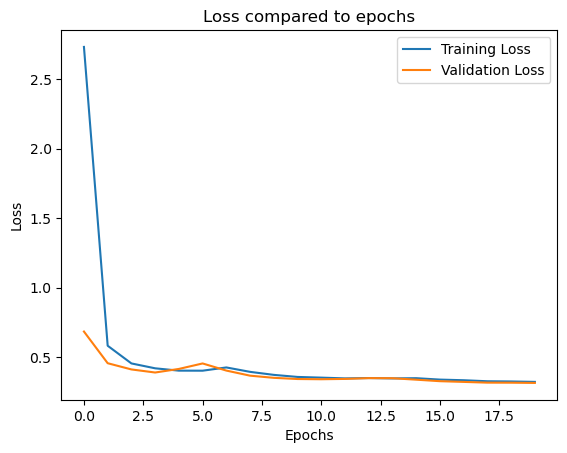

In [16]:
plt.plot(model_history.history["loss"],label="Training Loss")
plt.plot(model_history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.title("Loss compared to epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [17]:
model.evaluate(X_test,y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3270


0.3270188271999359